In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import gc

PROCESSED = Path("../data/processed")
REPORTS = Path("reports")
REPORTS.mkdir(exist_ok=True)

pd.set_option("display.max_columns", 200)
sns.set_style("whitegrid")

df = pd.read_parquet(PROCESSED / "application_train_clean.parquet")
print(f"Shape: {df.shape}")
print(f"Memoria: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

Shape: (307511, 128)
Memoria: 348.1 MB


In [2]:
families = {
    "loan_financials": ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE"],
    "demographics": ["CODE_GENDER", "AGE_YEARS", "NAME_FAMILY_STATUS", "CNT_CHILDREN",
                     "CNT_FAM_MEMBERS", "NAME_HOUSING_TYPE"],
    "employment": ["NAME_INCOME_TYPE", "OCCUPATION_TYPE", "ORGANIZATION_TYPE",
                   "EMPLOYMENT_YEARS", "DAYS_EMPLOYED_ANOM", "NAME_EDUCATION_TYPE"],
    "ext_sources": ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"],
    "region": ["REGION_POPULATION_RELATIVE", "REGION_RATING_CLIENT",
               "REGION_RATING_CLIENT_W_CITY"],
    "social_circle": ["OBS_30_CNT_SOCIAL_CIRCLE", "DEF_30_CNT_SOCIAL_CIRCLE",
                      "OBS_60_CNT_SOCIAL_CIRCLE", "DEF_60_CNT_SOCIAL_CIRCLE"],
    "bureau_queries": [c for c in df.columns if c.startswith("AMT_REQ_CREDIT_BUREAU_")],
}

doc_flags = [c for c in df.columns if c.startswith("FLAG_DOCUMENT_")]
contact_flags = ["FLAG_MOBIL", "FLAG_EMP_PHONE", "FLAG_WORK_PHONE",
                 "FLAG_CONT_MOBILE", "FLAG_PHONE", "FLAG_EMAIL"]
addr_flags = ["REG_REGION_NOT_LIVE_REGION", "REG_REGION_NOT_WORK_REGION",
              "LIVE_REGION_NOT_WORK_REGION", "REG_CITY_NOT_LIVE_CITY",
              "REG_CITY_NOT_WORK_CITY", "LIVE_CITY_NOT_WORK_CITY"]
housing_avg = [c for c in df.columns if c.endswith("_AVG")]
housing_mode = [c for c in df.columns if c.endswith("_MODE")
                and c not in ("FONDKAPREMONT_MODE", "HOUSETYPE_MODE",
                              "WALLSMATERIAL_MODE", "EMERGENCYSTATE_MODE")]
housing_medi = [c for c in df.columns if c.endswith("_MEDI")]

print("Familias definidas:")
for k, v in families.items():
    print(f"  {k:20s}: {len(v):3d} columnas")
print(f"  {'doc_flags':20s}: {len(doc_flags):3d}")
print(f"  {'contact_flags':20s}: {len(contact_flags):3d}")
print(f"  {'addr_flags':20s}: {len(addr_flags):3d}")
print(f"  {'housing AVG/MODE/MEDI':20s}: {len(housing_avg)}/{len(housing_mode)}/{len(housing_medi)}")

Familias definidas:
  loan_financials     :   4 columnas
  demographics        :   6 columnas
  employment          :   6 columnas
  ext_sources         :   3 columnas
  region              :   3 columnas
  social_circle       :   4 columnas
  bureau_queries      :   6 columnas
  doc_flags           :  20
  contact_flags       :   6
  addr_flags          :   6
  housing AVG/MODE/MEDI: 14/15/14


In [3]:
n_anom = (df["DAYS_EMPLOYED_ANOM"] == 1).sum()
n_org_nan = df["ORGANIZATION_TYPE"].isna().sum()
both = ((df["DAYS_EMPLOYED_ANOM"] == 1) & (df["ORGANIZATION_TYPE"].isna())).sum()
print(f"DAYS_EMPLOYED_ANOM == 1:           {n_anom:,}")
print(f"ORGANIZATION_TYPE NaN (post-XNA):  {n_org_nan:,}")
print(f"Ambos simultáneamente:             {both:,}")

print(f"\nNAME_INCOME_TYPE entre los anómalos:")
print(df.loc[df["DAYS_EMPLOYED_ANOM"] == 1, "NAME_INCOME_TYPE"].value_counts())

print(f"\nTasa de default en el grupo anómalo vs el resto:")
print(df.groupby("DAYS_EMPLOYED_ANOM")["TARGET"].agg(["mean", "count"]).round(4))

DAYS_EMPLOYED_ANOM == 1:           55,374
ORGANIZATION_TYPE NaN (post-XNA):  55,374
Ambos simultáneamente:             55,374

NAME_INCOME_TYPE entre los anómalos:
NAME_INCOME_TYPE
Pensioner     55352
Unemployed       22
Name: count, dtype: int64

Tasa de default en el grupo anómalo vs el resto:
                      mean   count
DAYS_EMPLOYED_ANOM                
0                   0.0866  252137
1                   0.0540   55374


=== Estadísticas ===
       AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  AMT_GOODS_PRICE
count          307511.0    307511.0     307499.0         307233.0
mean           168798.0    599026.0      27109.0         538396.0
std            237123.0    402480.0      14493.0         369543.0
min             25650.0     45000.0       1616.0          40500.0
25%            112500.0    270000.0      16524.0         238500.0
50%            147150.0    513531.0      24903.0         450000.0
75%            202500.0    808650.0      34596.0         679500.0
max         117000000.0   4050000.0     258026.0        4050000.0

=== Asimetría y curtosis ===
                  skewness   kurtosis
AMT_INCOME_TOTAL    391.56  191786.55
AMT_CREDIT            1.23       1.93
AMT_ANNUITY           1.58       7.71
AMT_GOODS_PRICE       1.35       2.43


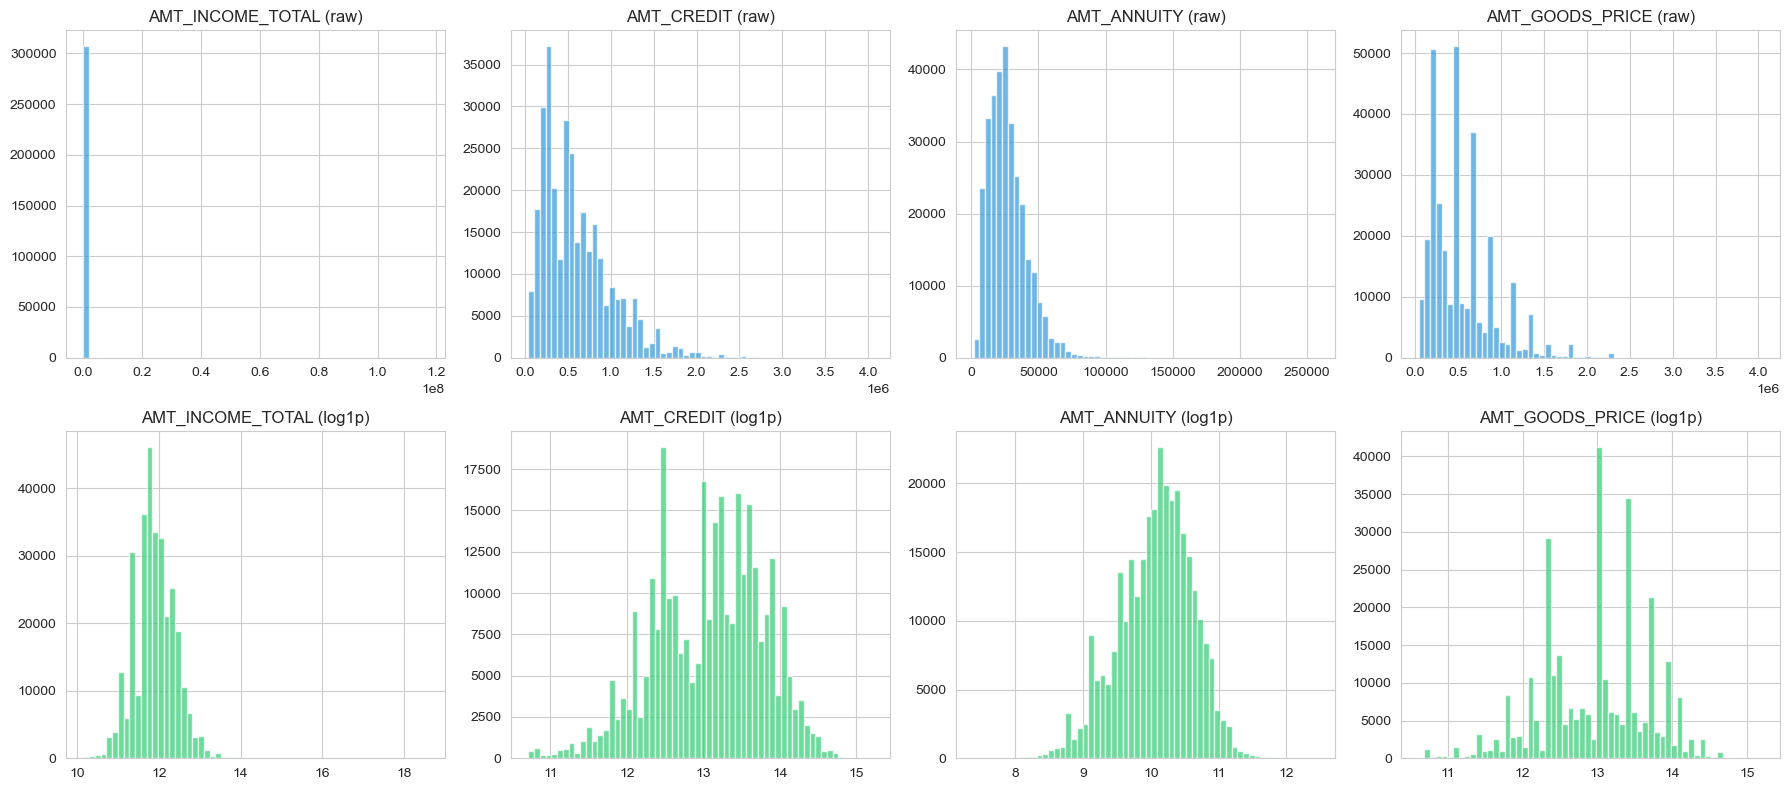

In [4]:
num_cols = families["loan_financials"]
print("=== Estadísticas ===")
print(df[num_cols].describe().round(0))

print("\n=== Asimetría y curtosis ===")
print(pd.DataFrame({
    "skewness": df[num_cols].skew().round(2),
    "kurtosis": df[num_cols].kurtosis().round(2),
}))

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for i, col in enumerate(num_cols):
    axes[0, i].hist(df[col].dropna(), bins=60, color="#3498db", alpha=0.7)
    axes[0, i].set_title(f"{col} (raw)")
    axes[1, i].hist(np.log1p(df[col].dropna()), bins=60, color="#2ecc71", alpha=0.7)
    axes[1, i].set_title(f"{col} (log1p)")
plt.tight_layout()
plt.savefig(REPORTS / "univar_loan_financials.png", dpi=80, bbox_inches="tight")
plt.show()

In [5]:
print("=== Categóricas ===")
for col in ["CODE_GENDER", "NAME_FAMILY_STATUS", "NAME_HOUSING_TYPE"]:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))

print("\n=== Numéricas ===")
print(df[["AGE_YEARS", "CNT_CHILDREN", "CNT_FAM_MEMBERS"]].describe().round(2))

=== Categóricas ===

--- CODE_GENDER ---
CODE_GENDER
F       202448
M       105059
None         4
Name: count, dtype: int64

--- NAME_FAMILY_STATUS ---
NAME_FAMILY_STATUS
Married                 196432
Single / not married     45444
Civil marriage           29775
Separated                19770
Widow                    16088
Unknown                      2
Name: count, dtype: int64

--- NAME_HOUSING_TYPE ---
NAME_HOUSING_TYPE
House / apartment      272868
With parents            14840
Municipal apartment     11183
Rented apartment         4881
Office apartment         2617
Co-op apartment          1122
Name: count, dtype: int64

=== Numéricas ===
       AGE_YEARS  CNT_CHILDREN  CNT_FAM_MEMBERS
count  307511.00     307511.00        307509.00
mean       43.91          0.42             2.15
std        11.95          0.72             0.91
min        20.50          0.00             1.00
25%        33.98          0.00             2.00
50%        43.12          0.00             2.00
75%        

=== Estadísticas ===
       EXT_SOURCE_1  EXT_SOURCE_2  EXT_SOURCE_3
count   134133.0000   306851.0000   246546.0000
mean         0.5021        0.5144        0.5109
std          0.2111        0.1911        0.1948
min          0.0146        0.0000        0.0005
25%          0.3340        0.3925        0.3706
50%          0.5060        0.5660        0.5353
75%          0.6751        0.6636        0.6691
max          0.9627        0.8550        0.8960

=== % de nulos ===
EXT_SOURCE_1    56.38
EXT_SOURCE_2     0.21
EXT_SOURCE_3    19.83
dtype: float64

=== Correlación entre ellas ===
              EXT_SOURCE_1  EXT_SOURCE_2  EXT_SOURCE_3
EXT_SOURCE_1         1.000         0.214         0.187
EXT_SOURCE_2         0.214         1.000         0.109
EXT_SOURCE_3         0.187         0.109         1.000

=== AUC univariada vs TARGET ===
  EXT_SOURCE_1: AUC = 0.6657  (raw 0.3343)
  EXT_SOURCE_2: AUC = 0.6561  (raw 0.3439)
  EXT_SOURCE_3: AUC = 0.6794  (raw 0.3206)


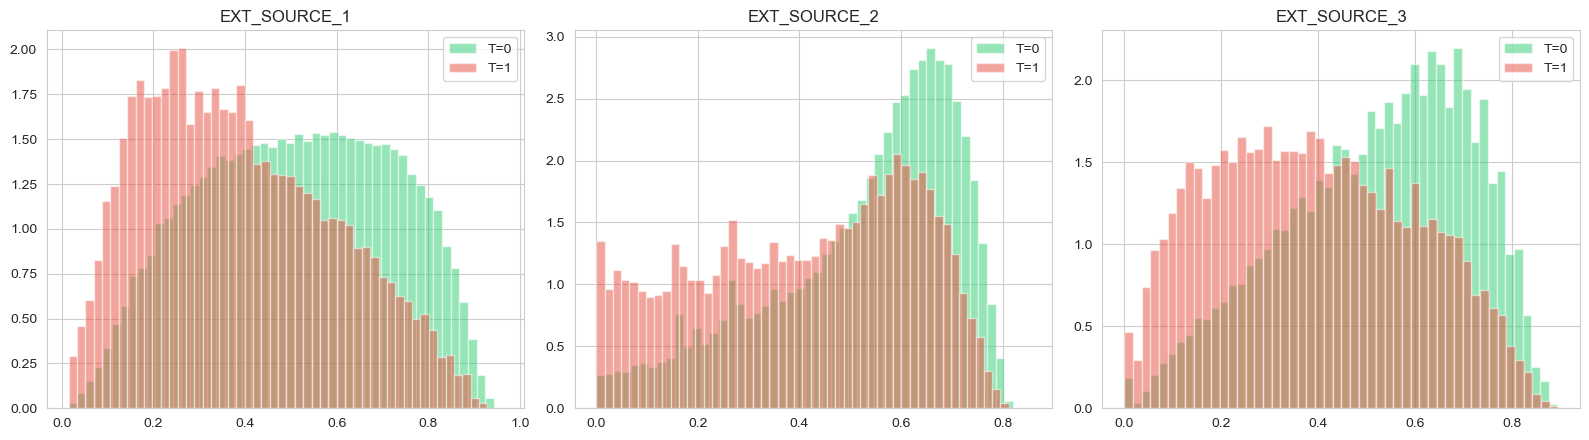

In [6]:
from sklearn.metrics import roc_auc_score

ext = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]
print("=== Estadísticas ===")
print(df[ext].describe().round(4))

print("\n=== % de nulos ===")
print((df[ext].isna().mean() * 100).round(2))

print("\n=== Correlación entre ellas ===")
print(df[ext].corr().round(3))

print("\n=== AUC univariada vs TARGET ===")
for col in ext:
    m = df[col].notna()
    auc = roc_auc_score(df.loc[m, "TARGET"], df.loc[m, col])
    # Si la relación es inversa, la AUC ‘real’ es 1-auc
    print(f"  {col}: AUC = {max(auc, 1-auc):.4f}  (raw {auc:.4f})")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for i, col in enumerate(ext):
    for t, color in [(0, "#2ecc71"), (1, "#e74c3c")]:
        s = df.loc[df["TARGET"] == t, col].dropna()
        axes[i].hist(s, bins=50, alpha=0.5, density=True, label=f"T={t}", color=color)
    axes[i].set_title(col); axes[i].legend()
plt.tight_layout()
plt.savefig(REPORTS / "univar_ext_sources.png", dpi=80, bbox_inches="tight")
plt.show()

In [7]:
roots = sorted(set(c.replace("_AVG", "") for c in housing_avg))
correl_summary = []
for root in roots:
    triplet = [f"{root}_AVG", f"{root}_MODE", f"{root}_MEDI"]
    triplet = [c for c in triplet if c in df.columns]
    if len(triplet) >= 2:
        corr = df[triplet].corr()
        upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        avg_corr = upper.stack().mean()
        correl_summary.append({
            "raiz": root,
            "n_variantes": len(triplet),
            "corr_interna_media": round(avg_corr, 3),
        })

corr_df = pd.DataFrame(correl_summary).sort_values("corr_interna_media", ascending=False)
print("Correlación interna media de cada raíz housing (AVG/MODE/MEDI):")
print(corr_df.to_string(index=False))
print(f"\nMedia global de correlaciones internas: {corr_df['corr_interna_media'].mean():.3f}")

Correlación interna media de cada raíz housing (AVG/MODE/MEDI):
                   raiz  n_variantes  corr_interna_media
            YEARS_BUILD            3               0.992
              FLOORSMIN            3               0.991
              FLOORSMAX            3               0.990
              ELEVATORS            3               0.986
              ENTRANCES            3               0.985
             COMMONAREA            3               0.984
             APARTMENTS            3               0.982
           BASEMENTAREA            3               0.982
               LANDAREA            3               0.982
             LIVINGAREA            3               0.981
       LIVINGAPARTMENTS            3               0.980
    NONLIVINGAPARTMENTS            3               0.980
          NONLIVINGAREA            3               0.977
YEARS_BEGINEXPLUATATION            3               0.976

Media global de correlaciones internas: 0.983


In [8]:
doc_sum = df[doc_flags].sum().sort_values(ascending=False)
doc_pct = (100 * doc_sum / len(df)).round(2)
doc_table = pd.DataFrame({"n_con_flag": doc_sum.astype(int), "pct": doc_pct})
print("=== FLAG_DOCUMENT_* (activación) ===")
print(doc_table)

# Feature agregada
df["DOCUMENTS_PROVIDED_COUNT"] = df[doc_flags].sum(axis=1).astype("int8")
print("\nDistribución del conteo de docs por cliente:")
print(df["DOCUMENTS_PROVIDED_COUNT"].value_counts().sort_index())

# Flags con casi cero varianza
low_var_docs = doc_pct[doc_pct < 0.1].index.tolist()
print(f"\nFLAG_DOCUMENT_* con activación <0.1% ({len(low_var_docs)} cols): {low_var_docs}")

=== FLAG_DOCUMENT_* (activación) ===
                  n_con_flag    pct
FLAG_DOCUMENT_3       218340  71.00
FLAG_DOCUMENT_6        27078   8.81
FLAG_DOCUMENT_8        25024   8.14
FLAG_DOCUMENT_5         4648   1.51
FLAG_DOCUMENT_16        3053   0.99
FLAG_DOCUMENT_18        2500   0.81
FLAG_DOCUMENT_11        1203   0.39
FLAG_DOCUMENT_9         1198   0.39
FLAG_DOCUMENT_13        1084   0.35
FLAG_DOCUMENT_14         903   0.29
FLAG_DOCUMENT_15         372   0.12
FLAG_DOCUMENT_19         183   0.06
FLAG_DOCUMENT_20         156   0.05
FLAG_DOCUMENT_21         103   0.03
FLAG_DOCUMENT_17          82   0.03
FLAG_DOCUMENT_7           59   0.02
FLAG_DOCUMENT_4           25   0.01
FLAG_DOCUMENT_2           13   0.00
FLAG_DOCUMENT_10           7   0.00
FLAG_DOCUMENT_12           2   0.00

Distribución del conteo de docs por cliente:
DOCUMENTS_PROVIDED_COUNT
0     29549
1    270056
2      7742
3       163
4         1
Name: count, dtype: int64

FLAG_DOCUMENT_* con activación <0.1% (9 cols): ['

In [9]:
print("=== Contact flags ===")
print((df[contact_flags].mean() * 100).round(2))

print("\n=== Address mismatch flags ===")
print((df[addr_flags].mean() * 100).round(2))

print("\n=== Social circle ===")
sc = families["social_circle"]
print(df[sc].describe().round(2))
print("\nMedia por TARGET:")
print(df.groupby("TARGET")[sc].mean().round(3))

=== Contact flags ===
FLAG_MOBIL          100.00
FLAG_EMP_PHONE       81.99
FLAG_WORK_PHONE      19.94
FLAG_CONT_MOBILE     99.81
FLAG_PHONE           28.11
FLAG_EMAIL            5.67
dtype: float64

=== Address mismatch flags ===
REG_REGION_NOT_LIVE_REGION      1.51
REG_REGION_NOT_WORK_REGION      5.08
LIVE_REGION_NOT_WORK_REGION     4.07
REG_CITY_NOT_LIVE_CITY          7.82
REG_CITY_NOT_WORK_CITY         23.05
LIVE_CITY_NOT_WORK_CITY        17.96
dtype: float64

=== Social circle ===
       OBS_30_CNT_SOCIAL_CIRCLE  DEF_30_CNT_SOCIAL_CIRCLE  \
count                 306490.00                 306490.00   
mean                       1.42                      0.14   
std                        2.40                      0.45   
min                        0.00                      0.00   
25%                        0.00                      0.00   
50%                        0.00                      0.00   
75%                        2.00                      0.00   
max                  

In [10]:
cat_cols = df.select_dtypes(include="object").columns.tolist()
card = pd.DataFrame({
    "n_unique": df[cat_cols].nunique(),
    "n_null": df[cat_cols].isna().sum(),
    "top_category": [df[c].mode(dropna=True).iloc[0] if df[c].notna().any() else None for c in cat_cols],
    "top_pct": [round(100 * df[c].value_counts(normalize=True).iloc[0], 2) if df[c].notna().any() else 0 for c in cat_cols],
}).sort_values("n_unique", ascending=False)
print("Cardinalidad de variables categóricas:")
print(card)

Cardinalidad de variables categóricas:
                            n_unique  n_null                   top_category  \
ORGANIZATION_TYPE                 57   55374         Business Entity Type 3   
OCCUPATION_TYPE                   18   96391                       Laborers   
NAME_INCOME_TYPE                   8       0                        Working   
NAME_TYPE_SUITE                    7    1292                  Unaccompanied   
WALLSMATERIAL_MODE                 7  156341                          Panel   
WEEKDAY_APPR_PROCESS_START         7       0                        TUESDAY   
NAME_FAMILY_STATUS                 6       0                        Married   
NAME_HOUSING_TYPE                  6       0              House / apartment   
NAME_EDUCATION_TYPE                5       0  Secondary / secondary special   
FONDKAPREMONT_MODE                 4  210295               reg oper account   
HOUSETYPE_MODE                     3  154297                 block of flats   
FLAG_OWN_REAL

In [11]:
print("=== Decisiones tentativas para Fase 2C / Feature Engineering ===\n")

high_null_housing = [c for c in df.columns
                     if c.endswith(("_AVG", "_MODE", "_MEDI"))
                     and df[c].isna().mean() > 0.5]
print(f"1) Housing con >50% nulos: {len(high_null_housing)} columnas")
print(f"   Estrategia tentativa: quedarnos solo con sufijo _AVG y descartar _MODE/_MEDI.")

low_var_docs = [c for c in doc_flags if df[c].mean() < 0.001]
print(f"\n2) FLAG_DOCUMENT_* con <0.1% activación: {len(low_var_docs)} columnas → descartar.")

# Flags constantes (varianza cero)
const_cols = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
print(f"\n3) Columnas con varianza cero: {const_cols}")

# FLAG_MOBIL (sospecha de constante)
print(f"\n4) FLAG_MOBIL value_counts: {df['FLAG_MOBIL'].value_counts().to_dict()}")

=== Decisiones tentativas para Fase 2C / Feature Engineering ===

1) Housing con >50% nulos: 39 columnas
   Estrategia tentativa: quedarnos solo con sufijo _AVG y descartar _MODE/_MEDI.

2) FLAG_DOCUMENT_* con <0.1% activación: 9 columnas → descartar.

3) Columnas con varianza cero: []

4) FLAG_MOBIL value_counts: {1: 307510, 0: 1}


In [12]:
df.to_parquet(PROCESSED / "application_train_clean.parquet", index=False)
print("Actualizado: application_train_clean.parquet (con DOCUMENTS_PROVIDED_COUNT)")

Actualizado: application_train_clean.parquet (con DOCUMENTS_PROVIDED_COUNT)
